# 2. RFM + K-Means Customer Segmentation

This notebook segments customers from the processed H&M artifacts using RFM features and K-Means clustering.

**Deterministic settings:** fixed random seeds, fixed K search range, explicit `FINAL_K` override.

**Leakage rule:** all modeling steps use **train_processed.parquet** only.

## 1. Setup and Reproducibility

In [1]:
from pathlib import Path
import warnings

import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import PowerTransformer, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

print("Libraries imported. Seed set to", SEED)

Libraries imported. Seed set to 42


In [2]:
# Resolve project root robustly whether notebook is run from repository root or notebooks/
cwd = Path.cwd()
if (cwd / "data" / "processed").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "processed").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not locate data/processed from current working directory.")

DATA_DIR = PROJECT_ROOT / "data" / "processed"
TRAIN_PATH = DATA_DIR / "train_processed.parquet"
CUSTOMERS_PATH = DATA_DIR / "customers_processed.parquet"
OUTPUT_PATH = DATA_DIR / "customers_segmented.parquet"

required_files = [TRAIN_PATH, CUSTOMERS_PATH]
missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required processed artifacts:\n"
        + "\n".join(missing)
        + "\n\nPlease generate these files before running this notebook."
    )

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAIN_PATH:", TRAIN_PATH)
print("CUSTOMERS_PATH:", CUSTOMERS_PATH)
print("OUTPUT_PATH:", OUTPUT_PATH)

PROJECT_ROOT: d:\_Python\Year3_Semester2\DDM\final_group_project\hm-recommendation-system
TRAIN_PATH: d:\_Python\Year3_Semester2\DDM\final_group_project\hm-recommendation-system\data\processed\train_processed.parquet
CUSTOMERS_PATH: d:\_Python\Year3_Semester2\DDM\final_group_project\hm-recommendation-system\data\processed\customers_processed.parquet
OUTPUT_PATH: d:\_Python\Year3_Semester2\DDM\final_group_project\hm-recommendation-system\data\processed\customers_segmented.parquet


## 2. Data Loading and RFM Aggregation (Polars Lazy)

In [3]:
train_lf = pl.scan_parquet(str(TRAIN_PATH))
customers_lf = pl.scan_parquet(str(CUSTOMERS_PATH)).select(["customer_id", "age"])

rfm_lf = (
    train_lf
    .group_by("customer_id")
    .agg([
        pl.col("days_ago").min().alias("R"),
        pl.col("t_dat").n_unique().alias("F"),
        (pl.col("price") * pl.col("quantity")).sum().alias("M"),
    ])
    .join(customers_lf, on="customer_id", how="left")
    .select(["customer_id", "R", "F", "M", "age"])
)

rfm_df = rfm_lf.collect()

# Defensive age handling in case unexpected nulls are present.
if rfm_df.get_column("age").null_count() > 0:
    # Calculate median strictly from the active training population, ignoring nulls
    fallback_age = int(rfm_df.get_column("age").drop_nulls().median())
    rfm_df = rfm_df.with_columns(pl.col("age").fill_null(fallback_age))
    print(f"Filled null age values with fallback median age: {fallback_age}")

rfm_df = rfm_df.with_columns([
    pl.col("R").cast(pl.Float64),
    pl.col("F").cast(pl.Float64),
    pl.col("M").cast(pl.Float64),
    pl.col("age").cast(pl.Float64),
])

print("Aggregated rows (customers with train transactions):", rfm_df.height)
rfm_df.head()

Aggregated rows (customers with train transactions): 1338789


customer_id,R,F,M,age
i32,f64,f64,f64,f64
21368,101.0,1.0,0.076237,21.0
601281,59.0,1.0,0.076203,21.0
962536,226.0,3.0,0.460695,50.0
238436,472.0,1.0,0.042356,21.0
946137,57.0,7.0,1.129898,35.0


In [4]:
# Aggregation QA checks
assert rfm_df.height > 0, "No customers found in training data."
assert rfm_df.get_column("customer_id").is_duplicated().sum() == 0, "Duplicate customer_id detected after aggregation."
assert rfm_df.filter(pl.col("R") < 0).height == 0, "Recency contains negative values."
assert rfm_df.filter(pl.col("F") < 1).height == 0, "Frequency must be at least 1."
assert rfm_df.filter(pl.col("M") < 0).height == 0, "Monetary contains negative values."

null_summary = rfm_df.select([pl.col(c).is_null().sum().alias(c) for c in rfm_df.columns])
print("Null counts by column:")
print(null_summary)

Null counts by column:
shape: (1, 5)
┌─────────────┬─────┬─────┬─────┬─────┐
│ customer_id ┆ R   ┆ F   ┆ M   ┆ age │
│ ---         ┆ --- ┆ --- ┆ --- ┆ --- │
│ u32         ┆ u32 ┆ u32 ┆ u32 ┆ u32 │
╞═════════════╪═════╪═════╪═════╪═════╡
│ 0           ┆ 0   ┆ 0   ┆ 0   ┆ 0   │
└─────────────┴─────┴─────┴─────┴─────┘


## 3. Feature Transformation and Scaling

In [5]:
# Keep explicit mapping order between model matrix and customer_id
model_df = rfm_df.select(["customer_id", "R", "F", "M", "age"])
customer_id_array = model_df.get_column("customer_id").to_numpy()

rfm_matrix = model_df.select(["R", "F", "M"]).to_numpy()
age_matrix = model_df.select(["age"]).to_numpy()

power_transformer = PowerTransformer(method="yeo-johnson", standardize=False)
rfm_transformed = power_transformer.fit_transform(rfm_matrix)

X_pre_scaled = np.hstack([rfm_transformed, age_matrix])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pre_scaled)

print("Scaled matrix shape:", X_scaled.shape)
print("Customer ID mapping length:", len(customer_id_array))
assert X_scaled.shape[0] == len(customer_id_array), "Feature matrix and customer_id mapping are misaligned."

Scaled matrix shape: (1338789, 4)
Customer ID mapping length: 1338789


## 4. Optimal K Discovery on 100k Sample

In [6]:
sample_n = min(100_000, X_scaled.shape[0])
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(X_scaled.shape[0], size=sample_n, replace=False)
X_sample = X_scaled[sample_idx]

k_values = list(range(3, 11))
wcss = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, init="k-means++", random_state=SEED, n_init=10)
    sample_labels = km.fit_predict(X_sample)
    wcss.append(km.inertia_)

    # Deterministic silhouette approximation for tractability on large samples.
    sil = silhouette_score(
        X_sample,
        sample_labels,
        sample_size=min(20_000, sample_n),
        random_state=SEED,
    )
    sil_scores.append(sil)

k_metrics_df = pl.DataFrame({
    "k": k_values,
    "wcss": wcss,
    "silhouette": sil_scores,
})

k_metrics_df

k,wcss,silhouette
i64,f64,f64
3,169361.089695,0.340717
4,140149.365882,0.311752
5,119249.781437,0.299283
6,104226.781256,0.303873
7,93976.164535,0.29819
8,85945.124287,0.291272
9,79111.871066,0.294031
10,74056.249774,0.288169


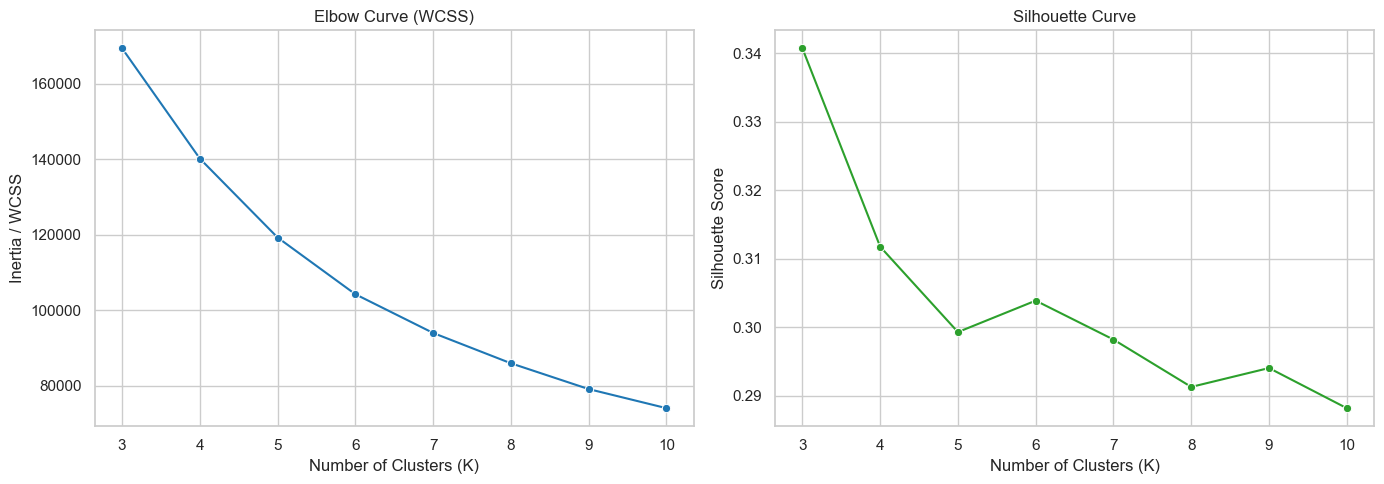

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(x=k_values, y=wcss, marker="o", ax=axes[0], color="#1f77b4")
axes[0].set_title("Elbow Curve (WCSS)")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia / WCSS")

sns.lineplot(x=k_values, y=sil_scores, marker="o", ax=axes[1], color="#2ca02c")
axes[1].set_title("Silhouette Curve")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

### K-Selection Rationale: Mathematical Signal vs. Business Utility

The Silhouette curve indicates that **K=3** provides the strongest compactness/separation tradeoff.

For marketing operations, we intentionally keep **FINAL_K = 5** to preserve actionable granularity:
- separate very recent low-frequency customers (`Newcomers`) from stale low-frequency customers (`At-Risk`),
- isolate high-value heavy buyers (`Whales`) from strong but less extreme loyal customers (`Champions`).

This is a deliberate business decision, not an arbitrary override of the mathematical optimum.

In [8]:
# Manually set this after reviewing the Elbow and Silhouette curves.
FINAL_K = 5
assert 3 <= FINAL_K <= 10, "FINAL_K must be between 3 and 10."
print("Using FINAL_K =", FINAL_K)

Using FINAL_K = 5


## 5. Final Clustering and Centroid Profiling

In [9]:
final_kmeans = KMeans(
    n_clusters=FINAL_K,
    init="k-means++",
    random_state=SEED,
    n_init=10,
)

cluster_id = final_kmeans.fit_predict(X_scaled).astype(np.int32)

clustered_df = model_df.with_columns(pl.Series(name="cluster_id", values=cluster_id))

cluster_profile_df = (
    clustered_df
    .group_by("cluster_id")
    .agg([
        pl.col("R").mean().alias("R_mean"),
        pl.col("R").median().alias("R_median"),
        pl.col("F").mean().alias("F_mean"),
        pl.col("F").median().alias("F_median"),
        pl.col("M").mean().alias("M_mean"),
        pl.col("M").median().alias("M_median"),
        pl.col("age").mean().alias("age_mean"),
        pl.col("age").median().alias("age_median"),
        pl.len().alias("n_customers"),
    ])
    .sort("cluster_id")
)

global_medians = clustered_df.select([
    pl.col("R").median().alias("global_R_median"),
    pl.col("F").median().alias("global_F_median"),
    pl.col("M").median().alias("global_M_median"),
    pl.col("age").median().alias("global_age_median"),
]).to_dicts()[0]

cluster_profile_df

cluster_id,R_mean,R_median,F_mean,F_median,M_mean,M_median,age_mean,age_median,n_customers
i32,f64,f64,f64,f64,f64,f64,f64,f64,u32
0,439.589402,438.0,1.522144,1.0,0.12919,0.084712,27.527125,27.0,319027
1,87.230155,54.0,13.100569,9.0,1.258099,0.793297,52.267196,51.0,206882
2,364.743812,357.0,1.70864,1.0,0.139784,0.101661,53.759867,52.0,271554
3,73.338122,41.0,14.65036,11.0,1.537796,1.012949,27.04544,26.0,297709
4,91.567259,70.0,2.907383,3.0,0.209379,0.186322,26.496858,25.0,243617


## 6. Deterministic Business Labeling

In [10]:
profile_df = cluster_profile_df.select([
    "cluster_id", "R_median", "F_median", "M_median", "age_median"
]).sort("cluster_id")

global_F = float(global_medians["global_F_median"])
global_age = float(global_medians["global_age_median"])

remaining = set(profile_df.get_column("cluster_id").to_list())
base_labels = {int(cid): "Core" for cid in profile_df.get_column("cluster_id").to_list()}


def sort_remaining(df, remaining_ids):
    return df.filter(pl.col("cluster_id").is_in(list(remaining_ids)))


def pick_first(df):
    if df.height == 0:
        return None
    return int(df["cluster_id"][0])

# 1) Whales: highest median monetary
whales_candidates = (
    sort_remaining(profile_df, remaining)
    .sort(["M_median", "R_median", "F_median"], descending=[True, False, True])
)
whales_cid = pick_first(whales_candidates)
if whales_cid is not None:
    base_labels[whales_cid] = "Whales"
    remaining.remove(whales_cid)

# 2) At-Risk: highest median recency
risk_candidates = (
    sort_remaining(profile_df, remaining)
    .sort(["R_median", "F_median", "M_median"], descending=[True, False, False])
)
at_risk_cid = pick_first(risk_candidates)
if at_risk_cid is not None:
    base_labels[at_risk_cid] = "At-Risk"
    remaining.remove(at_risk_cid)

# 3) Champions: lowest recency among high-frequency clusters in remaining set
champ_pool = sort_remaining(profile_df, remaining).filter(pl.col("F_median") >= global_F)
if champ_pool.height == 0:
    champ_pool = sort_remaining(profile_df, remaining)
champions_candidates = champ_pool.sort(["R_median", "M_median", "F_median"], descending=[False, True, True])
champions_cid = pick_first(champions_candidates)
if champions_cid is not None:
    base_labels[champions_cid] = "Champions"
    remaining.remove(champions_cid)

# 4) Newcomers: lowest frequency and low recency among remaining clusters
newcomers_candidates = (
    sort_remaining(profile_df, remaining)
    .sort(["F_median", "R_median", "M_median"], descending=[False, False, False])
)
newcomers_cid = pick_first(newcomers_candidates)
if newcomers_cid is not None:
    base_labels[newcomers_cid] = "Newcomers"
    remaining.remove(newcomers_cid)

# Optional explicit names for any unlabeled residual clusters
for cid in sorted(remaining):
    base_labels[cid] = "Core"

# Rule guards for deterministic business logic
if whales_cid is not None:
    whales_m = profile_df.filter(pl.col("cluster_id") == whales_cid).item(0, "M_median")
    assert whales_m == profile_df.get_column("M_median").max(), "Whales rule violated: not highest Monetary median."

if at_risk_cid is not None:
    risk_r = profile_df.filter(pl.col("cluster_id") == at_risk_cid).item(0, "R_median")
    assert risk_r == profile_df.get_column("R_median").max(), "At-Risk rule violated: not highest Recency median."

if champions_cid is not None:
    excluded = [cid for cid in [whales_cid, at_risk_cid] if cid is not None]
    eligible = profile_df.filter(
        (pl.col("F_median") >= global_F) & (~pl.col("cluster_id").is_in(excluded))
    )
    if eligible.height > 0:
        champ_r = profile_df.filter(pl.col("cluster_id") == champions_cid).item(0, "R_median")
        assert champ_r == eligible.get_column("R_median").min(), "Champions rule violated in eligible high-F pool."

age_by_cluster = {
    int(row["cluster_id"]): float(row["age_median"])
    for row in profile_df.iter_rows(named=True)
}

final_label_map = {}
for cid, base in base_labels.items():
    prefix = "Young" if age_by_cluster[cid] < global_age else "Mature"
    final_label_map[cid] = f"{prefix} {base}"

label_df = pl.DataFrame({
    "cluster_id": list(final_label_map.keys()),
    "segment_label": list(final_label_map.values()),
})

segmented_df = clustered_df.join(label_df, on="cluster_id", how="left")

assert segmented_df.get_column("segment_label").null_count() == 0, "Some customers are missing segment labels."

cluster_profile_with_labels = (
    cluster_profile_df
    .join(label_df, on="cluster_id", how="left")
    .sort("cluster_id")
)

cluster_profile_with_labels

cluster_id,R_mean,R_median,F_mean,F_median,M_mean,M_median,age_mean,age_median,n_customers,segment_label
i32,f64,f64,f64,f64,f64,f64,f64,f64,u32,str
0,439.589402,438.0,1.522144,1.0,0.12919,0.084712,27.527125,27.0,319027,"""Young At-Risk"""
1,87.230155,54.0,13.100569,9.0,1.258099,0.793297,52.267196,51.0,206882,"""Mature Champions"""
2,364.743812,357.0,1.70864,1.0,0.139784,0.101661,53.759867,52.0,271554,"""Mature Newcomers"""
3,73.338122,41.0,14.65036,11.0,1.537796,1.012949,27.04544,26.0,297709,"""Young Whales"""
4,91.567259,70.0,2.907383,3.0,0.209379,0.186322,26.496858,25.0,243617,"""Young Core"""


## 7. Basket Context

This table measures basket density as the average `quantity` per interaction for each segment. It supports downstream Market Basket Analysis with segment-specific transaction intensity.

In [11]:
basket_context_df = (
    train_lf
    .group_by(["customer_id", "t_dat"])  # 1. Isolate distinct baskets
    .agg(pl.col("quantity").sum().alias("basket_size"))  # 2. Sum items per basket
    .join(segmented_df.lazy().select(["customer_id", "segment_label", "cluster_id"]), on="customer_id", how="inner")
    .group_by("segment_label")
    .agg([
        pl.col("basket_size").mean().alias("avg_basket_size"),
        pl.len().alias("n_interactions"),  # This now represents total distinct baskets
    ])
    .sort("avg_basket_size", descending=True)
    .collect()
)

basket_context_df


segment_label,avg_basket_size,n_interactions
str,f64,u32
"""Young Whales""",3.806173,4361544
"""Mature Champions""",3.337485,2710272
"""Young At-Risk""",3.283255,485605
"""Mature Newcomers""",2.93846,463988
"""Young Core""",2.936644,708288


## 8. Summary Table 

This summary consolidates segment size, population share, behavioral medians, and basket density into a single handover table for RecSys and MBA teammates.

In [12]:
segment_summary_df = (
    segmented_df
    .group_by("segment_label")
    .agg([
        pl.len().alias("N"),
        pl.col("R").median().alias("R_median"),
        pl.col("F").median().alias("F_median"),
        pl.col("M").median().alias("M_median"),
        pl.col("age").median().alias("Age_median"),
    ])
    .with_columns((pl.col("N") / segmented_df.height * 100).alias("Population_Share_Pct"))
    .join(
        basket_context_df.select(["segment_label", "avg_basket_size"]),
        on="segment_label",
        how="left",
    )
    .with_columns([
        pl.col("Population_Share_Pct").round(2),
        pl.col("M_median").round(6),
        pl.col("avg_basket_size").round(4),
    ])
    .select([
        "segment_label",
        "N",
        "Population_Share_Pct",
        "R_median",
        "F_median",
        "M_median",
        "Age_median",
        "avg_basket_size",
    ])
    .sort("Population_Share_Pct", descending=True)
)

segment_summary_df

segment_label,N,Population_Share_Pct,R_median,F_median,M_median,Age_median,avg_basket_size
str,u32,f64,f64,f64,f64,f64,f64
"""Young At-Risk""",319027,23.83,438.0,1.0,0.084712,27.0,3.2833
"""Young Whales""",297709,22.24,41.0,11.0,1.012949,26.0,3.8062
"""Mature Newcomers""",271554,20.28,357.0,1.0,0.101661,52.0,2.9385
"""Young Core""",243617,18.2,70.0,3.0,0.186322,25.0,2.9366
"""Mature Champions""",206882,15.45,54.0,9.0,0.793297,51.0,3.3375


## 9. Segment Heatmap (Normalized Medians)

This view compares segment centroids on a normalized scale to make cross-feature differences visually interpretable.

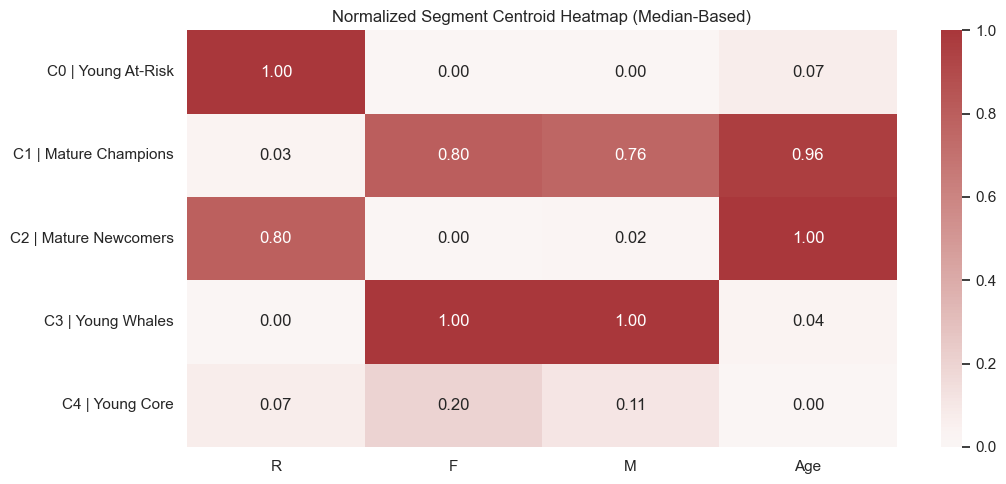

In [13]:
centroid_df = (
    segmented_df
    .group_by(["cluster_id", "segment_label"])
    .agg([
        pl.col("R").median().alias("R"),
        pl.col("F").median().alias("F"),
        pl.col("M").median().alias("M"),
        pl.col("age").median().alias("age"),
    ])
    .sort("cluster_id")
)

from sklearn.preprocessing import MinMaxScaler  # Import added here for convenience

centroid_matrix = centroid_df.select(["R", "F", "M", "age"]).to_numpy()
centroid_matrix_norm = MinMaxScaler().fit_transform(centroid_matrix)

row_labels = [f"C{cid} | {label}" for cid, label in centroid_df.select(["cluster_id", "segment_label"]).iter_rows()]
col_labels = ["R", "F", "M", "Age"]

plt.figure(figsize=(11, 5))
sns.heatmap(
    centroid_matrix_norm,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    xticklabels=col_labels,
    yticklabels=row_labels,
)
plt.title("Normalized Segment Centroid Heatmap (Median-Based)")
plt.tight_layout()
plt.show()

## 10. Export and Final QA

Before export, schema is tightened (`age` -> Int8, `cluster_id` -> Int32) to stay compatible with downstream joins and source conventions.

In [14]:
# Revenue Share Computation
segment_revenue_df = (
    segmented_df
    .group_by("segment_label")
    .agg(pl.col("M").sum().alias("total_M"))
    .with_columns((pl.col("total_M") / pl.col("total_M").sum() * 100).alias("Revenue_Share_Pct"))
    .sort("Revenue_Share_Pct", descending=True)
)
print(segment_revenue_df)

# Pareto / Quantile Boundary Computation
high_value_pool = segmented_df.filter(pl.col("segment_label").is_in(["Young Whales", "Mature Champions"]))
low_value_pool = segmented_df.filter(pl.col("segment_label").is_in(["Young Core", "Mature Newcomers"]))

print("Q25 High Value:", high_value_pool.get_column("M").quantile(0.25))
print("Q75 Low Value:", low_value_pool.get_column("M").quantile(0.75))

final_df = (
    segmented_df
    .select(["customer_id", "R", "F", "M", "age", "cluster_id", "segment_label"])
    .with_columns([
        pl.col("customer_id").cast(pl.Int32),
        pl.col("R").cast(pl.Float64),
        pl.col("F").cast(pl.Float64),
        pl.col("M").cast(pl.Float64),
        pl.col("age").round(0).cast(pl.Int8),
        pl.col("cluster_id").cast(pl.Int32),
    ])
 )

# QA: no nulls, unique customers, complete assignment coverage
assert final_df.height == rfm_df.height, "Mismatch in customer counts after segmentation."
assert final_df.get_column("customer_id").is_duplicated().sum() == 0, "Duplicate customer_id in output."

null_counts = final_df.select([pl.col(c).is_null().sum().alias(c) for c in final_df.columns])
total_nulls = int(sum(null_counts.row(0)))
assert total_nulls == 0, f"Output contains null values: {null_counts}"

inf_counts = final_df.select([
    pl.col("R").is_infinite().sum().alias("R_inf"),
    pl.col("F").is_infinite().sum().alias("F_inf"),
    pl.col("M").is_infinite().sum().alias("M_inf"),
])
assert int(sum(inf_counts.row(0))) == 0, f"Output contains inf values: {inf_counts}"

assert final_df.get_column("segment_label").null_count() == 0, "Missing segment labels in final output."

final_df.write_parquet(OUTPUT_PATH)

print("Export complete:", OUTPUT_PATH)
print("Rows exported:", final_df.height)
print("Distinct segments:", final_df.get_column("segment_label").n_unique())
print("Output schema:", final_df.schema)

final_df.head()

shape: (5, 3)
┌──────────────────┬───────────────┬───────────────────┐
│ segment_label    ┆ total_M       ┆ Revenue_Share_Pct │
│ ---              ┆ ---           ┆ ---               │
│ str              ┆ f64           ┆ f64               │
╞══════════════════╪═══════════════╪═══════════════════╡
│ Young Whales     ┆ 457815.842458 ┆ 53.970153         │
│ Mature Champions ┆ 260278.014508 ┆ 30.683176         │
│ Young Core       ┆ 51008.273966  ┆ 6.01317           │
│ Young At-Risk    ┆ 41214.990644  ┆ 4.858677          │
│ Mature Newcomers ┆ 37958.855153  ┆ 4.474824          │
└──────────────────┴───────────────┴───────────────────┘
Q25 High Value: 0.5690169491525423
Q75 Low Value: 0.24389830508474575
Export complete: d:\_Python\Year3_Semester2\DDM\final_group_project\hm-recommendation-system\data\processed\customers_segmented.parquet
Rows exported: 1338789
Distinct segments: 5
Output schema: Schema({'customer_id': Int32, 'R': Float64, 'F': Float64, 'M': Float64, 'age': Int8, 'cluster_

customer_id,R,F,M,age,cluster_id,segment_label
i32,f64,f64,f64,i8,i32,str
21368,101.0,1.0,0.076237,21,4,"""Young Core"""
601281,59.0,1.0,0.076203,21,4,"""Young Core"""
962536,226.0,3.0,0.460695,50,2,"""Mature Newcomers"""
238436,472.0,1.0,0.042356,21,0,"""Young At-Risk"""
946137,57.0,7.0,1.129898,35,3,"""Young Whales"""
